# ALGORITHM 1 (TT1): VOICE ACTIVITY DETECTION (VAD)
## SHORT-TIME ENERGY (STE) OPTIMIZATION VIA BINARY SEARCH

### 1. Environment Configuration and Library Imports
Import standard numerical and audio utilities, initialize `IPython.display.Audio`, and define framing parameters.

In [30]:
from pathlib import Path
import wave
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "TinHieuHuanLuyen").exists() and (candidate / "TinHieuKiemThu").exists():
            return candidate
    return Path.cwd()

PROJECT_ROOT = find_project_root()
TRAIN_DIR = PROJECT_ROOT / "TinHieuHuanLuyen"
TEST_DIR = PROJECT_ROOT / "TinHieuKiemThu"
OUTPUT_DIR = PROJECT_ROOT / "src" / "TT1" / "output" / "main"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Standardized DSP parameters
FRAME_MS = 25        # Frame length (ms)
HOP_MS = 10          # Frame hop (ms)
MIN_SILENCE_MS = 200 # Minimum silence bridging threshold (ms)

### 2. Audio Reading (16-bit PCM WAV)
Load audio stream, normalize amplitude into `[-1.0, 1.0]`, and retrieve sample rate `fs`.

In [31]:
def read_wav(wav_path):
    """Read 16-bit PCM WAV, normalize amplitude to [-1, 1], return fs and max amplitude."""
    with wave.open(str(wav_path), "rb") as wf:
        fs = wf.getframerate()
        samples = wf.readframes(wf.getnframes())
    signal = np.frombuffer(samples, dtype=np.int16).astype(float)
    max_amp = np.max(np.abs(signal))
    return signal / max_amp, fs, max_amp

### 3. Praat Ground-Truth Parsing (.lab)
Parse phonetic time intervals and extract ground-truth speech boundaries from voiced (`v`) and unvoiced (`uv`) segments.

In [32]:
def read_lab(lab_path):
    """Read Praat .lab file, return ground-truth speech boundaries (start, end)."""
    speech = []
    for line in lab_path.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) == 3 and parts[2].lower() in {"v", "uv"}:
            speech.append((float(parts[0]), float(parts[1])))
    return round(min(s[0] for s in speech), 4), round(max(s[1] for s in speech), 4)

### 4. Normalized Short-Time Energy (STE) Computation
Frame the signal and compute normalized mean squared energy `STE_norm` $\in [0, 1]$ per frame.

In [33]:
def compute_ste(signal, fs, frame_ms=FRAME_MS, hop_ms=HOP_MS):
    """Frame signal and compute normalized short-time energy [0, 1]."""
    frame_size = int(round(frame_ms * fs / 1000.0))
    hop_size = int(round(hop_ms * fs / 1000.0))
    n_frames = max(1, int(np.ceil(max(0, len(signal) - frame_size) / hop_size)) + 1)

    ste = np.zeros(n_frames)
    frame_starts = np.zeros(n_frames)
    for i in range(n_frames):
        start = i * hop_size
        frame = np.zeros(frame_size)
        avail = signal[start : min(start + frame_size, len(signal))]
        frame[:len(avail)] = avail
        ste[i] = np.mean(frame ** 2)
        frame_starts[i] = start / fs

    max_ste = float(np.max(ste))
    ste_norm = ste / max(max_ste, 1e-12)
    return ste_norm, frame_starts, max_ste

### 5. Binary Search Energy VAD Model Class
Formulate threshold bisection optimization to eliminate signed speech duration errors on the training set.

In [34]:
class EnergyBinarySearchVAD:
    """Binary search VAD model optimizing STE threshold on signed duration error."""
    def __init__(self, epochs=40, search_range=(1e-4, 0.05)):
        self.epochs = epochs
        self.search_range = search_range
        self.threshold = None
        # Lists tracking threshold T and loss metrics across epochs
        self.t_list = []
        self.loss_mae = []
        self.loss_rmse = []
        self.mae_list = self.loss_mae    # alias
        self.rmse_list = self.loss_rmse  # alias

    def predict(self, ste_norm, frame_starts, duration, threshold=None):
        """Classify frames with threshold T and bridge silences < 200 ms."""
        if threshold is None:
            threshold = self.threshold
        labels = (ste_norm >= threshold).astype(int)
        min_silence_frames = int(round(MIN_SILENCE_MS / HOP_MS))
        speech_idx = np.flatnonzero(labels == 1)
        if len(speech_idx) == 0:
            return (0.0, 0.0), labels

        idx, last = int(speech_idx[0]), int(speech_idx[-1])
        while idx <= last:
            if labels[idx] == 1:
                idx += 1
            else:
                sil_start = idx
                while idx <= last and labels[idx] == 0:
                    idx += 1
                if idx - sil_start < min_silence_frames:
                    labels[sil_start:idx] = 1

        speech_idx = np.flatnonzero(labels == 1)
        start_time = float(frame_starts[speech_idx[0]])
        end_time = min(duration, float(frame_starts[speech_idx[-1]] + FRAME_MS / 1000.0))
        return (round(start_time, 4), round(end_time, 4)), labels

    def fit(self, train_data):
        """Train threshold bisection across 40 epochs."""
        low, high = self.search_range
        self.t_list = []
        self.loss_mae = []
        self.loss_rmse = []
        self.mae_list = self.loss_mae    # alias
        self.rmse_list = self.loss_rmse  # alias
        print(f"Starting binary search on range [{low:.6f}, {high:.6f}] ({self.epochs} epochs):")
        print("-" * 96)
        for epoch in range(1, self.epochs + 1):
            threshold = (low + high) / 2.0
            duration_errors, maes, rmses = [], [], []
            for item in train_data:
                pred_bounds, _ = self.predict(item["ste_norm"], item["frame_starts"], item["duration"], threshold)
                pred_dur = pred_bounds[1] - pred_bounds[0]
                true_dur = item["gt_bounds"][1] - item["gt_bounds"][0]
                duration_errors.append(pred_dur - true_dur)
                d_st = (pred_bounds[0] - item["gt_bounds"][0]) * 1000.0
                d_en = (pred_bounds[1] - item["gt_bounds"][1]) * 1000.0
                maes.append((abs(d_st) + abs(d_en)) / 2.0)
                rmses.append(np.sqrt((d_st**2 + d_en**2) / 2.0))

            mean_error = float(np.mean(duration_errors))
            epoch_mae = float(np.mean(maes))
            epoch_rmse = float(np.mean(rmses))

            # Record T, Loss MAE, and Loss RMSE per epoch
            self.t_list.append(threshold)
            self.loss_mae.append(epoch_mae)
            self.loss_rmse.append(epoch_rmse)

            if epoch <= 10 or epoch % 5 == 0 or epoch == self.epochs:
                print(f"Epoch {epoch:02d} | T = {threshold:.8f} | Bias = {mean_error:+.4f} s | Train MAE = {epoch_mae:5.2f} ms | Train RMSE = {epoch_rmse:5.2f} ms")

            if mean_error > 0:
                low = threshold
            else:
                high = threshold

        self.threshold = (low + high) / 2.0
        print("-" * 96)
        print(f">>> OPTIMAL STE THRESHOLD ACQUIRED: T = {self.threshold:.8f}")
        return self

### 6. Training Dataset Ingestion
Load 4 training recordings (`phone_F1`, `phone_M1`, `studio_F1`, `studio_M1`) with ground-truth boundaries.

In [35]:
train_data = []
for wav_file in sorted(TRAIN_DIR.glob("*.wav")):
    signal, fs, max_amp = read_wav(wav_file)
    ste_norm, frame_starts, max_ste = compute_ste(signal, fs)
    gt_bounds = read_lab(wav_file.with_suffix(".lab"))
    train_data.append({
        "name": wav_file.name,
        "ste_norm": ste_norm,
        "frame_starts": frame_starts,
        "duration": len(signal) / fs,
        "gt_bounds": gt_bounds,
        "max_amp": max_amp,
        "max_ste": max_ste,
    })
print(f"Loaded {len(train_data)} training files successfully.")

Loaded 4 training files successfully.


### 7. Binary Search Model Training
Execute 40-epoch bisection training to derive the global optimal threshold.

In [36]:
model = EnergyBinarySearchVAD(epochs=40)
model.fit(train_data)

Starting binary search on range [0.000100, 0.050000] (40 epochs):
------------------------------------------------------------------------------------------------
Epoch 01 | T = 0.02505000 | Bias = -0.0200 s | Train MAE = 13.75 ms | Train RMSE = 14.27 ms
Epoch 02 | T = 0.01257500 | Bias = -0.0150 s | Train MAE = 11.25 ms | Train RMSE = 12.39 ms
Epoch 03 | T = 0.00633750 | Bias = -0.0050 s | Train MAE = 10.00 ms | Train RMSE = 12.64 ms
Epoch 04 | T = 0.00321875 | Bias = +0.0000 s | Train MAE = 12.50 ms | Train RMSE = 15.08 ms
Epoch 05 | T = 0.00477813 | Bias = -0.0050 s | Train MAE = 10.00 ms | Train RMSE = 12.64 ms
Epoch 06 | T = 0.00399844 | Bias = -0.0025 s | Train MAE = 11.25 ms | Train RMSE = 14.31 ms
Epoch 07 | T = 0.00360859 | Bias = -0.0025 s | Train MAE = 11.25 ms | Train RMSE = 14.31 ms
Epoch 08 | T = 0.00341367 | Bias = +0.0000 s | Train MAE = 12.50 ms | Train RMSE = 15.08 ms
Epoch 09 | T = 0.00351113 | Bias = -0.0025 s | Train MAE = 11.25 ms | Train RMSE = 14.31 ms
Epoch 10 

### 8. Training Optimization History: Loss MAE & RMSE Progression
Inspect stored lists tracking threshold $T$, training MAE loss, and RMSE loss across 40 epochs, and visualize convergence dynamics.

Total epochs recorded: 40
1. Energy Threshold T list (first 5 epochs):        [0.02505, 0.012575, 0.006338, 0.003219, 0.004778]
2. Training Loss MAE list (first 5 epochs, ms):   [13.75, 11.25, 10.0, 12.5, 10.0]
3. Training Loss RMSE list (first 5 epochs, ms):  [14.27, 12.39, 12.64, 15.08, 12.64]

Epoch    | Threshold T    | Loss MAE (ms)    | Loss RMSE (ms)  
--------------------------------------------------------------------
1        | 0.02505000     | 13.75            | 14.27           
2        | 0.01257500     | 11.25            | 12.39           
3        | 0.00633750     | 10.00            | 12.64           
4        | 0.00321875     | 12.50            | 15.08           
5        | 0.00477813     | 10.00            | 12.64           
6        | 0.00399844     | 11.25            | 14.31           
7        | 0.00360859     | 11.25            | 14.31           
8        | 0.00341367     | 12.50            | 15.08           
9        | 0.00351113     | 11.25            | 14.31     

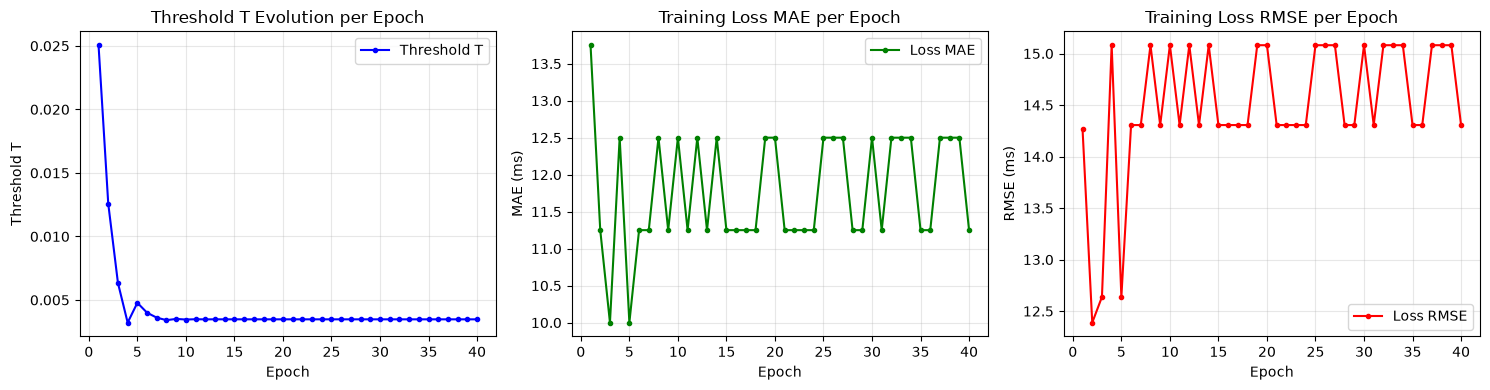

In [37]:
# Display stored training progression lists across epochs
print(f"Total epochs recorded: {len(model.t_list)}")
print(f"1. Energy Threshold T list (first 5 epochs):        {[round(x, 6) for x in model.t_list[:5]]}")
print(f"2. Training Loss MAE list (first 5 epochs, ms):   {[round(x, 2) for x in model.loss_mae[:5]]}")
print(f"3. Training Loss RMSE list (first 5 epochs, ms):  {[round(x, 2) for x in model.loss_rmse[:5]]}")

# Detailed overview table across key training epochs
print("\n" + "=" * 68)
print(f"{'Epoch':<8} | {'Threshold T':<14} | {'Loss MAE (ms)':<16} | {'Loss RMSE (ms)':<16}")
print("-" * 68)
for ep, (t_val, mae_val, rmse_val) in enumerate(zip(model.t_list, model.loss_mae, model.loss_rmse), start=1):
    if ep <= 10 or ep % 5 == 0 or ep == len(model.t_list):
        print(f"{ep:<8} | {t_val:<14.8f} | {mae_val:<16.2f} | {rmse_val:<16.2f}")
print("=" * 68)

# Full raw lists
print("\nFull raw lists:")
print(f"- model.t_list   = {[round(x, 8) for x in model.t_list]}")
print(f"- model.loss_mae = {[round(x, 2) for x in model.loss_mae]}")
print(f"- model.loss_rmse= {[round(x, 2) for x in model.loss_rmse]}")

# Visualize all 3 tracking lists across epochs
epochs = range(1, len(model.t_list) + 1)
plt.figure(figsize=(15, 4), dpi=100)

plt.subplot(1, 3, 1)
plt.plot(epochs, model.t_list, 'b.-', label="Threshold T")
plt.title("Threshold T Evolution per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Threshold T")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, model.loss_mae, 'g.-', label="Loss MAE")
plt.title("Training Loss MAE per Epoch")
plt.xlabel("Epoch")
plt.ylabel("MAE (ms)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, model.loss_rmse, 'r.-', label="Loss RMSE")
plt.title("Training Loss RMSE per Epoch")
plt.xlabel("Epoch")
plt.ylabel("RMSE (ms)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### 9. Physical Scale Threshold Mapping
Map normalized $T_{opt}$ back to unnormalized energy levels and amplitude scales.

In [38]:
print(">>> THRESHOLD MAPPING TO PHYSICAL UNITS:")
for item in train_data:
    t_raw_ste = model.threshold * item["max_ste"]
    t_amp = np.sqrt(model.threshold) * item["max_amp"]
    print(f"  {item['name']:<15} (max_amp = {item['max_amp']:>7.0f}, max_ste = {item['max_ste']:.4f}) -> Raw STE = {t_raw_ste:.6f} | Equivalent Amp = {t_amp:.1f}")

>>> THRESHOLD MAPPING TO PHYSICAL UNITS:
  phone_F1.wav    (max_amp =   28896, max_ste = 0.1658) -> Raw STE = 0.000577 | Equivalent Amp = 1704.1
  phone_M1.wav    (max_amp =   16146, max_ste = 0.0581) -> Raw STE = 0.000202 | Equivalent Amp = 952.2
  studio_F1.wav   (max_amp =   18889, max_ste = 0.0530) -> Raw STE = 0.000184 | Equivalent Amp = 1113.9
  studio_M1.wav   (max_amp =   22462, max_ste = 0.0470) -> Raw STE = 0.000164 | Equivalent Amp = 1324.6


### 10. Quantitative Test Benchmark Evaluation
Apply the optimized threshold to the 4 test recordings and report MAE and RMSE metrics.

In [39]:
test_results_dict = {}
test_results = []
print("=" * 96)
print(f"{'QUANTITATIVE TEST SET BENCHMARK RESULTS':^96}")
print("=" * 96)
print(f"{'File':<16} | {'Ground Truth (s)':<16} | {'Prediction (s)':<16} | {'ΔStart':<10} | {'ΔEnd':<10} | {'MAE (ms)':<9} | {'RMSE (ms)':<9}")
print("-" * 96)

for wav_file in sorted(TEST_DIR.glob("*.wav")):
    signal, fs, max_amp = read_wav(wav_file)
    duration = len(signal) / fs
    ste_norm, frame_starts, max_ste = compute_ste(signal, fs)
    gt = read_lab(wav_file.with_suffix(".lab"))
    pred, labels = model.predict(ste_norm, frame_starts, duration)

    d_start = (pred[0] - gt[0]) * 1000.0
    d_end = (pred[1] - gt[1]) * 1000.0
    mae = (abs(d_start) + abs(d_end)) / 2.0
    rmse = np.sqrt((d_start**2 + d_end**2) / 2.0)

    res_item = {
        "file": wav_file.name,
        "signal": signal,
        "fs": fs,
        "ste_norm": ste_norm,
        "frame_starts": frame_starts,
        "gt": gt,
        "pred": pred,
        "labels": labels,
        "d_start": d_start,
        "d_end": d_end,
        "mae": mae,
        "rmse": rmse,
    }
    test_results.append(res_item)
    test_results_dict[wav_file.name] = res_item

    gt_str = f"[{gt[0]:.2f}, {gt[1]:.2f}]"
    pred_str = f"[{pred[0]:.2f}, {pred[1]:.2f}]"
    print(f"{wav_file.name:<16} | {gt_str:<16} | {pred_str:<16} | {d_start:+8.1f} ms | {d_end:+8.1f} ms | {mae:9.2f} | {rmse:9.2f}")

mean_mae = np.mean([r["mae"] for r in test_results])
mean_rmse = np.mean([r["rmse"] for r in test_results])
print("-" * 96)
print(f"BENCHMARK SUMMARY:  Mean MAE = {mean_mae:.2f} ms  |  Mean RMSE = {mean_rmse:.2f} ms")
print("=" * 96)

                            QUANTITATIVE TEST SET BENCHMARK RESULTS                             
File             | Ground Truth (s) | Prediction (s)   | ΔStart     | ΔEnd       | MAE (ms)  | RMSE (ms)
------------------------------------------------------------------------------------------------
phone_F2.wav     | [1.02, 4.04]     | [1.01, 4.05]     |    -10.0 ms |    +15.0 ms |     12.50 |     12.75
phone_M2.wav     | [0.53, 2.52]     | [0.52, 2.52]     |    -10.0 ms |     -5.0 ms |      7.50 |      7.91
studio_F2.wav    | [0.77, 2.37]     | [0.76, 2.35]     |    -10.0 ms |    -15.0 ms |     12.50 |     12.75
studio_M2.wav    | [0.45, 1.93]     | [0.46, 1.94]     |    +10.0 ms |     +5.0 ms |      7.50 |      7.91
------------------------------------------------------------------------------------------------
BENCHMARK SUMMARY:  Mean MAE = 10.00 ms  |  Mean RMSE = 10.33 ms


### 11. Visualization Helper & Audio Player Integration
Plot detailed test waveforms, STE curves, decision boundaries, and render audio playback widgets.

In [40]:
def plot_and_play_test_file(res):
    """Plot test results and display embedded audio players."""
    fig, ax = plt.subplots(figsize=(13, 4.5))
    time_signal = np.arange(len(res["signal"])) / res["fs"]
    frame_centers = res["frame_starts"] + (FRAME_MS / 2000.0)

    ax.plot(time_signal, res["signal"], color="gray", linewidth=0.7, label="Normalized Waveform")
    ax.plot(frame_centers, res["ste_norm"], color="red", linewidth=1.1, label="Normalized STE")
    ax.axhline(model.threshold, color="blue", linestyle="--", linewidth=1.2, label=f"Threshold T = {model.threshold:.6f}")

    ax.fill_between(frame_centers, 0, 1, where=res["labels"] == 1, color="lightgreen", alpha=0.25, label="Predicted Speech Region")

    ax.axvline(res["gt"][0], color="red", linestyle="--", linewidth=1.8, label="Ground-truth Boundary (LAB)")
    ax.axvline(res["gt"][1], color="red", linestyle="--", linewidth=1.8)
    ax.axvline(res["pred"][0], color="green", linestyle=":", linewidth=2.2, label="Algorithm Predicted Boundary")
    ax.axvline(res["pred"][1], color="green", linestyle=":", linewidth=2.2)

    ax.set_title(f"{res['file']}  |  MAE = {res['mae']:.2f} ms  |  RMSE = {res['rmse']:.2f} ms", fontsize=12, fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude / STE")
    ax.set_ylim(-1.05, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

    info_text = (
        f"Ground-truth: [{res['gt'][0]:.2f}s, {res['gt'][1]:.2f}s]\n"
        f"Predicted:    [{res['pred'][0]:.2f}s, {res['pred'][1]:.2f}s]\n"
        f"ΔStart: {res['d_start']:+.1f} ms | ΔEnd: {res['d_end']:+.1f} ms\n"
        f"MAE: {res['mae']:.2f} ms | RMSE: {res['rmse']:.2f} ms"
    )
    ax.text(0.015, 0.95, info_text, transform=ax.transAxes, fontsize=9,
            verticalalignment="top", bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="gray"))

    plt.tight_layout()
    fig_path = OUTPUT_DIR / f"{Path(res['file']).stem}.png"
    plt.savefig(fig_path, dpi=150)
    print(f"Exported and saved figure: {fig_path}")
    plt.show()

    # Load and display local audio player widget
    wav_file_path = TEST_DIR / res['file']
    print(f"🎵 Original Audio ({res['file']}):")
    if wav_file_path.exists():
        display(Audio(filename=str(wav_file_path)))
    else:
        display(Audio(data=res['signal'], rate=res['fs']))

    # Display audio player for predicted speech segment
    st_sample = int(res['pred'][0] * res['fs'])
    en_sample = min(len(res['signal']), int(res['pred'][1] * res['fs']))
    if en_sample > st_sample:
        print(f"🔊 Predicted Speech Segment [{res['pred'][0]:.2f}s - {res['pred'][1]:.2f}s]:")
        display(Audio(data=res['signal'][st_sample:en_sample], rate=res['fs']))

### 12. Test Recording 1: `phone_F2.wav`
Telephone channel, female speaker. Waveform, STE overlay, and audio players.

Exported and saved figure: d:\DuyToan\DUT\Xử lý tín hiệu số\Midterm exam\K24\src\TT1\output\main\phone_F2.png


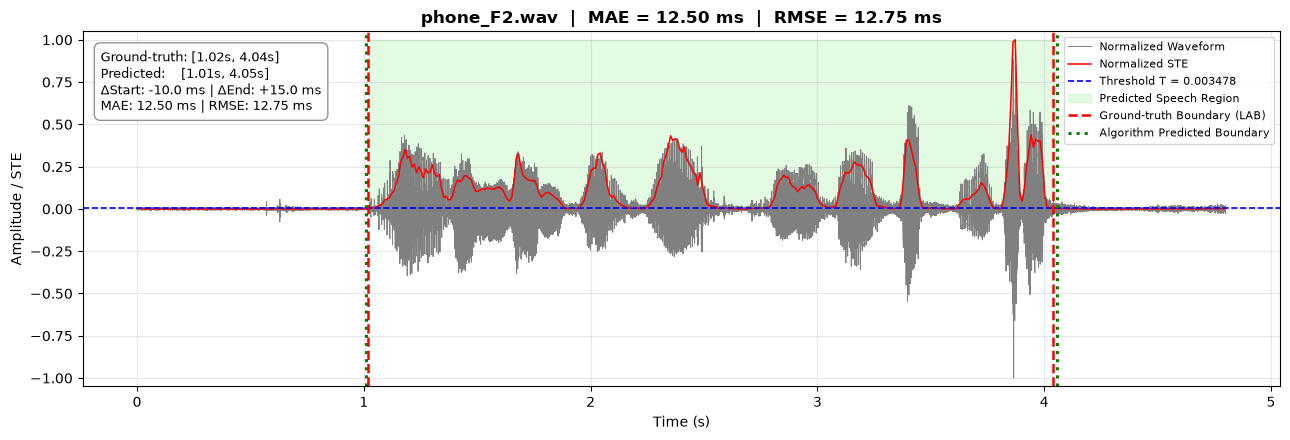

🎵 Original Audio (phone_F2.wav):


🔊 Predicted Speech Segment [1.01s - 4.05s]:


In [41]:
plot_and_play_test_file(test_results_dict["phone_F2.wav"])

### 13. Test Recording 2: `phone_M2.wav`
Telephone channel, male speaker. Waveform, STE overlay, and audio players.

Exported and saved figure: d:\DuyToan\DUT\Xử lý tín hiệu số\Midterm exam\K24\src\TT1\output\main\phone_M2.png


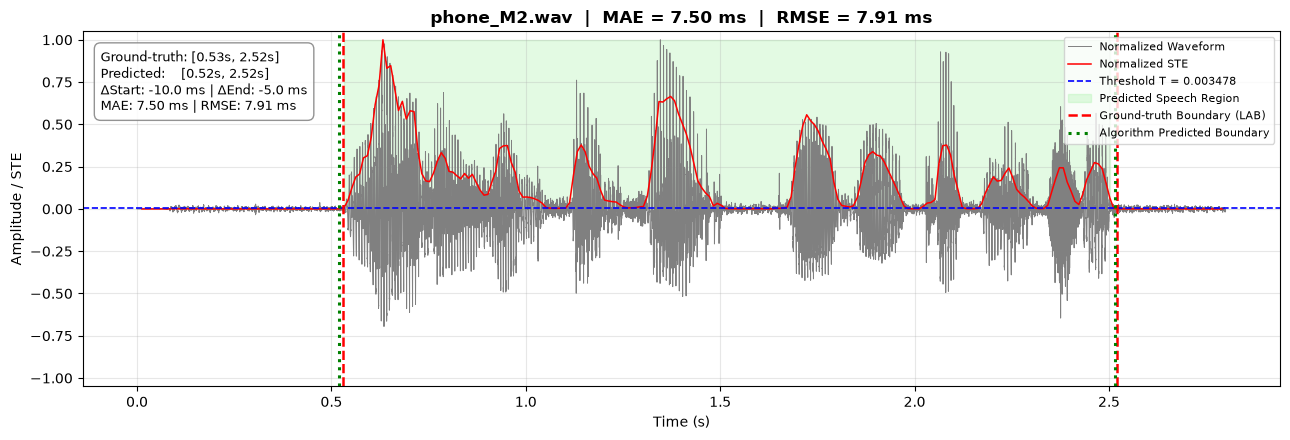

🎵 Original Audio (phone_M2.wav):


🔊 Predicted Speech Segment [0.52s - 2.52s]:


In [42]:
plot_and_play_test_file(test_results_dict["phone_M2.wav"])

### 14. Test Recording 3: `studio_F2.wav`
High SNR Studio environment, female speaker. Waveform, STE overlay, and audio players.

Exported and saved figure: d:\DuyToan\DUT\Xử lý tín hiệu số\Midterm exam\K24\src\TT1\output\main\studio_F2.png


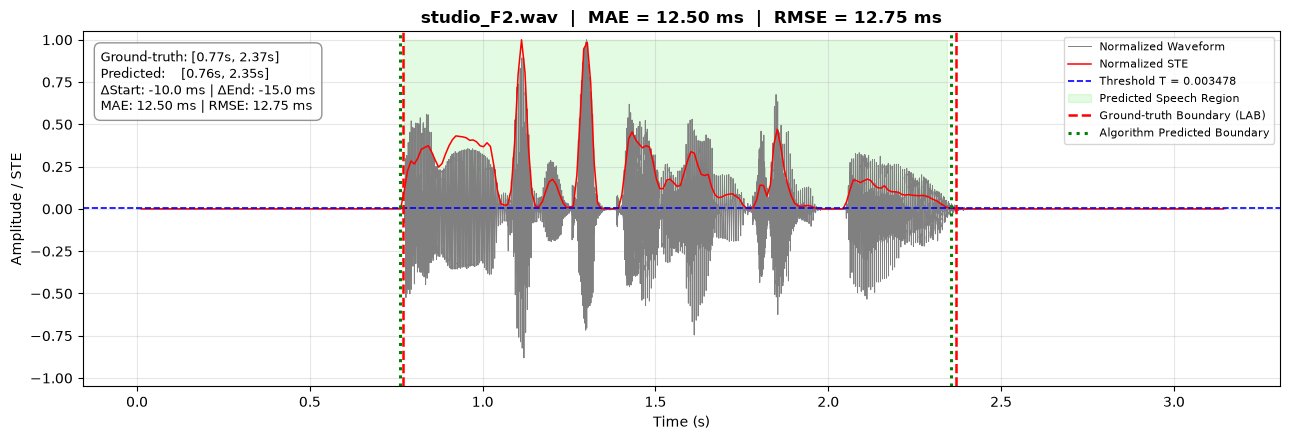

🎵 Original Audio (studio_F2.wav):


🔊 Predicted Speech Segment [0.76s - 2.35s]:


In [43]:
plot_and_play_test_file(test_results_dict["studio_F2.wav"])

### 15. Test Recording 4: `studio_M2.wav`
High SNR Studio environment, male speaker. Waveform, STE overlay, and audio players.

Exported and saved figure: d:\DuyToan\DUT\Xử lý tín hiệu số\Midterm exam\K24\src\TT1\output\main\studio_M2.png


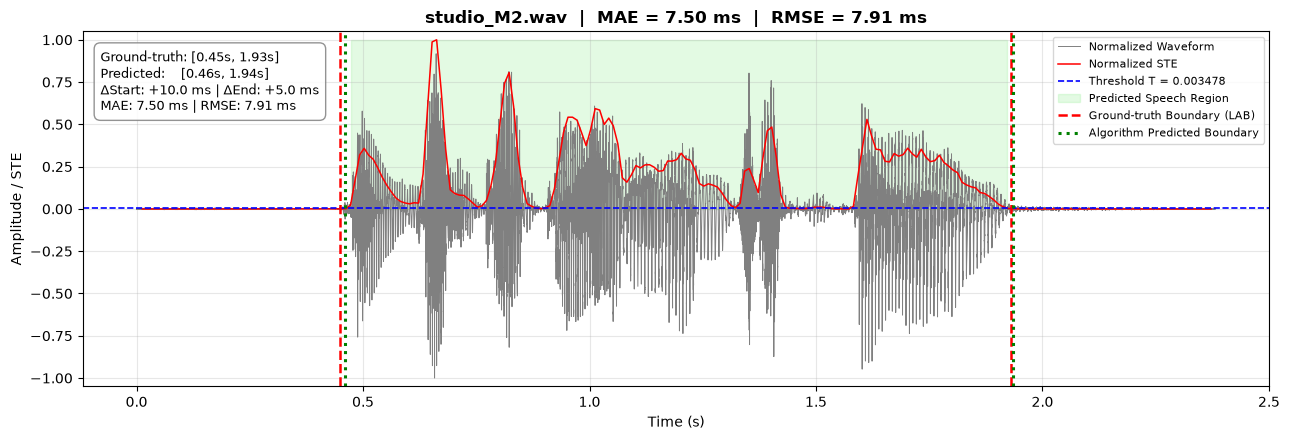

🎵 Original Audio (studio_M2.wav):


🔊 Predicted Speech Segment [0.46s - 1.94s]:


In [44]:
plot_and_play_test_file(test_results_dict["studio_M2.wav"])